<a href="https://colab.research.google.com/github/sansho-07/speech-emotion-detection/blob/main/speech_emotion_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Day 1

##Setup and uploading data and

In [273]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"saansho","key":"da617afd75fc75dff7f8684ca5f84dcb"}'}

In [274]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [275]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
ravdess-emotional-speech-audio.zip: Skipping, found more recently modified local copy (use --force to force download)


In [276]:
import zipfile
zip_path = "ravdess-emotional-speech-audio.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
  zip_ref.extractall("dataset")
print("Dataset extracted successfully")

Dataset extracted successfully


In [277]:
import os

dataset_path = "dataset"

print(os.listdir(dataset_path)[:5])

['Actor_09', 'Actor_23', 'Actor_14', 'Actor_01', 'Actor_20']


In [278]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

from tensorflow.keras.utils import to_categorical


audio_path = "dataset/Actor_01/03-01-01-01-01-01-01.wav"

audio_data, sample_rate = librosa.load(audio_path)

print("Sample Rate:",sample_rate)
print("Audio Shape:",audio_data.shape)

Sample Rate: 22050
Audio Shape: (72838,)


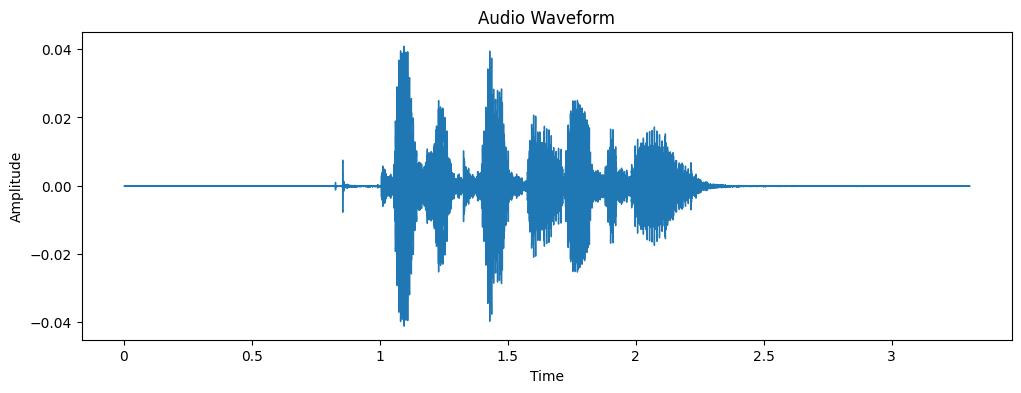

In [279]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(audio_data, sr=sample_rate)

plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

In [280]:
from IPython.display import Audio
Audio(audio_path)

#Day 2

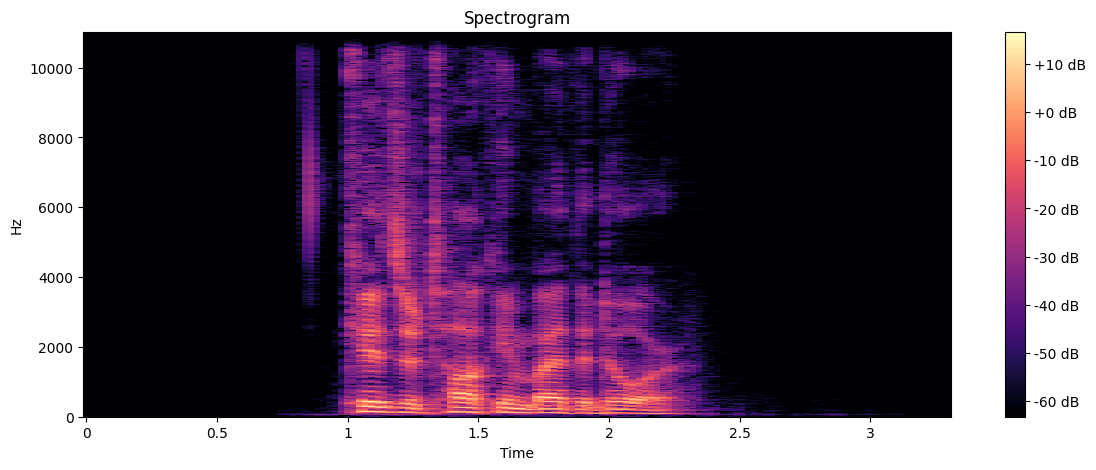

In [281]:
import numpy as np

spectrogram =librosa.stft(audio_data)

spectrogram_db = librosa.amplitude_to_db(np.abs(spectrogram))

plt.figure(figsize=(14,5))

librosa.display.specshow(
    spectrogram_db,
    sr = sample_rate,
    x_axis = 'time',
    y_axis = 'hz'
)

plt.colorbar(format= '%+2.0f dB')

plt.title("Spectrogram")

plt.show()

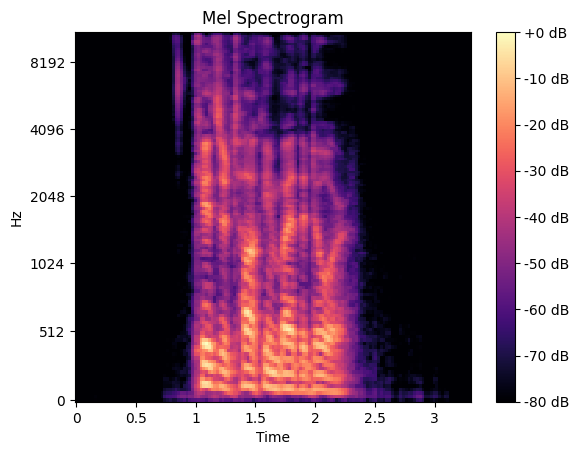

In [282]:
mel_spectrogram = librosa.feature.melspectrogram(
    y = audio_data,
    sr = sample_rate
)

mel_spectrogram_db = librosa.power_to_db(
    mel_spectrogram,
    ref = np.max
)

librosa.display.specshow(
    mel_spectrogram_db,
    sr = sample_rate,
    x_axis = 'time',
    y_axis = 'mel'
)

plt.colorbar(format = '%+2.0f dB')

plt.title("Mel Spectrogram")

plt.show()

In [283]:
duration = librosa.get_duration(y =audio_data,sr=sample_rate)

print("Audio Duration:", duration, "seconds")

Audio Duration: 3.3033106575963718 seconds


In [284]:
silent_parts = librosa.effects.split(audio_data)

print("Non-silent intervals")

print(silent_parts)

Non-silent intervals
[[17408 58368]
 [62464 64512]]


##Comparing Emotions (Happy VS Angry)

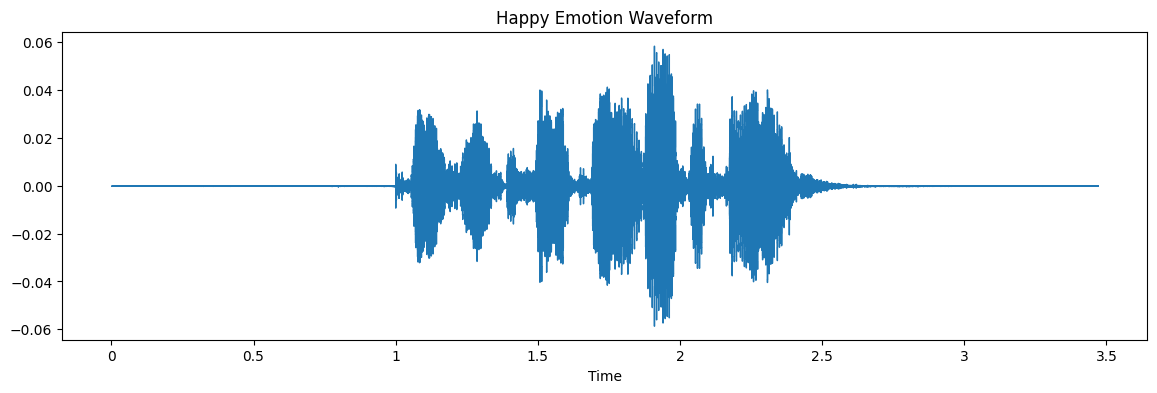

In [285]:
happy_audio = "dataset/Actor_01/03-01-03-01-01-01-01.wav"

happy_data, sr = librosa.load(happy_audio)

plt.figure(figsize=(14,4))

librosa.display.waveshow(happy_data,sr = sr)

plt.title("Happy Emotion Waveform")

plt.show()

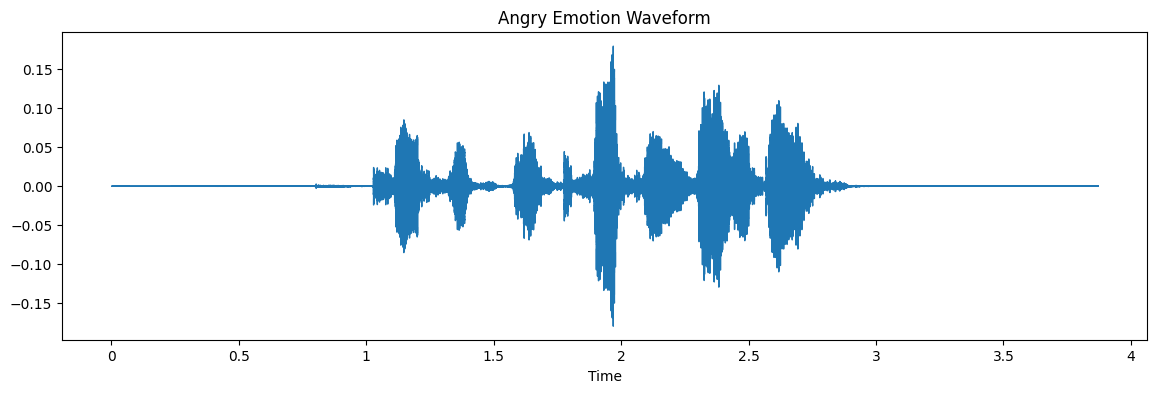

In [286]:
angry_audio = "dataset/Actor_01/03-01-05-01-01-01-01.wav"

angry_data, sr = librosa.load(angry_audio)

plt.figure(figsize=(14,4))

librosa.display.waveshow(angry_data, sr=sr)

plt.title("Angry Emotion Waveform")

plt.show()

Waveform image saved!


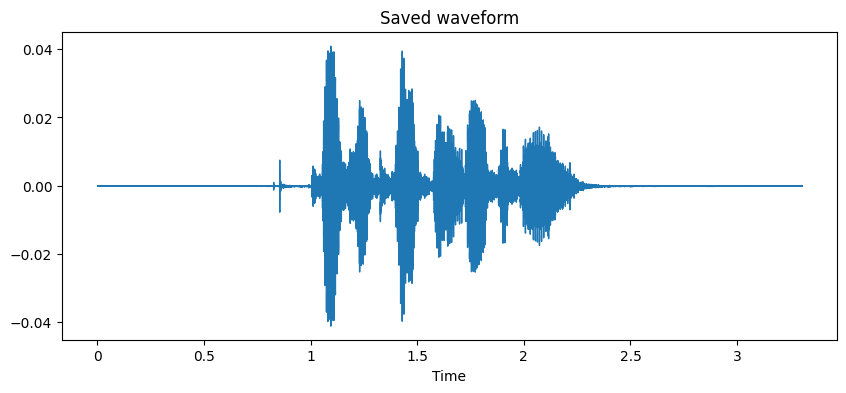

In [287]:
plt.figure(figsize=(10,4))

librosa.display.waveshow(audio_data,sr = sample_rate)

plt.title("Saved waveform")

plt.savefig("waveform.png")

print("Waveform image saved!")

#Day3

##Remove Silence

In [288]:
trimmed_audio, index = librosa.effects.trim(audio_data)

print("Original Length:", len(audio_data))
print("Trimmed Length:",len(trimmed_audio))

Original Length: 72838
Trimmed Length: 47104


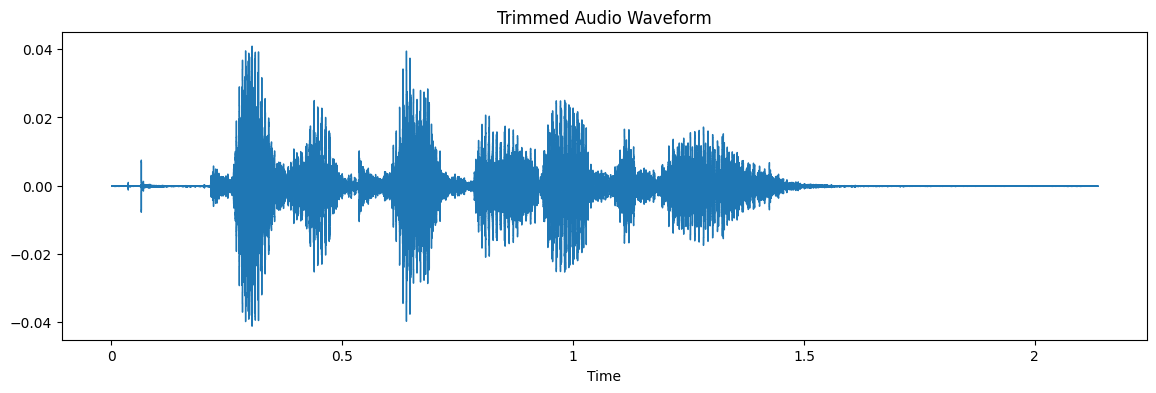

In [289]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(trimmed_audio,sr= sample_rate)

plt.title("Trimmed Audio Waveform")

plt.show()

##Normalization Audio


In [290]:
normalized_audio = librosa.util.normalize(trimmed_audio)

print("Normalization Complete")

Normalization Complete


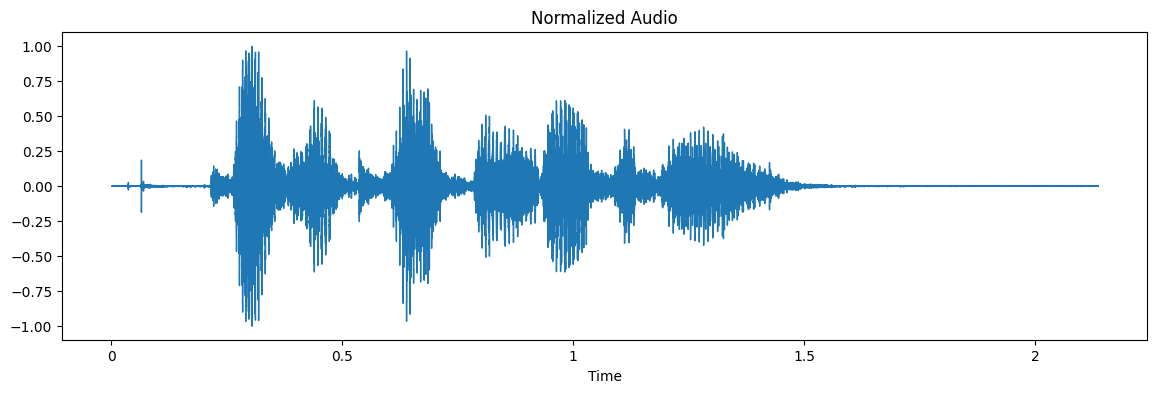

In [291]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(normalized_audio, sr = sample_rate)

plt.title("Normalized Audio")

plt.show()

##Standardize Audio Length


In [292]:
target_duration = 3
target_length = sample_rate*target_duration

print("Target Length:", target_length)

Target Length: 66150


##Pad or Trim Audio

In [293]:
if len(normalized_audio) > target_length:
  processed_audio = normalized_audio[:target_length]
else:
  padding = target_length- len(normalized_audio)
  processed_audio = np.pad(normalized_audio,(0,padding))

print("Processed Aidio Length:",len(processed_audio))

Processed Aidio Length: 66150


##Final Processed Waveform

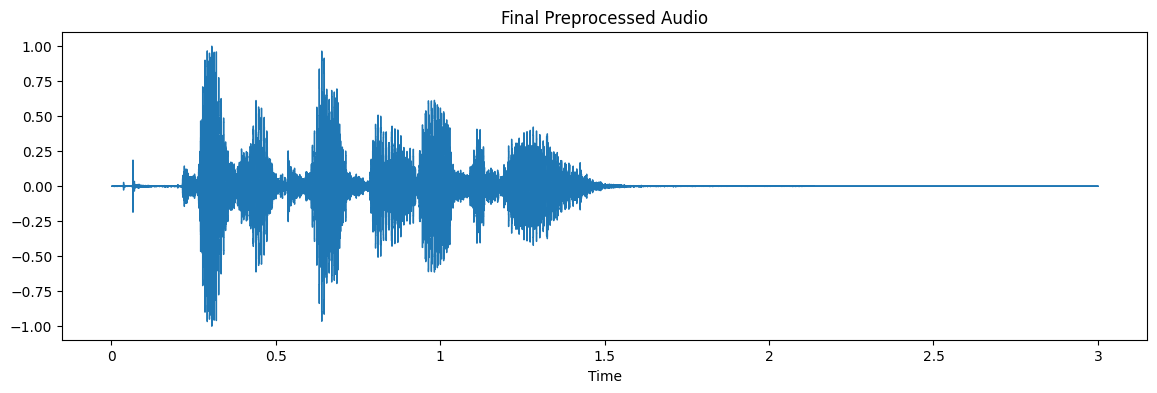

In [294]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(processed_audio, sr = sample_rate)

plt.title("Final Preprocessed Audio")

plt.show()

In [295]:
def preprocess_audio(audio_path, duration=3):

    audio, sr = librosa.load(audio_path)

    # Remove silence
    audio, _ = librosa.effects.trim(audio)

    # Normalize
    audio = librosa.util.normalize(audio)

    # Standardize length
    target_length = sr * duration

    if len(audio) > target_length:
        audio = audio[:target_length]
    else:
        padding = target_length - len(audio)
        audio = np.pad(audio, (0, padding))

    return audio, sr

In [296]:
processed_audio, sr = preprocess_audio(audio_path)

print("Processed Shape:", processed_audio.shape)

Processed Shape: (66150,)


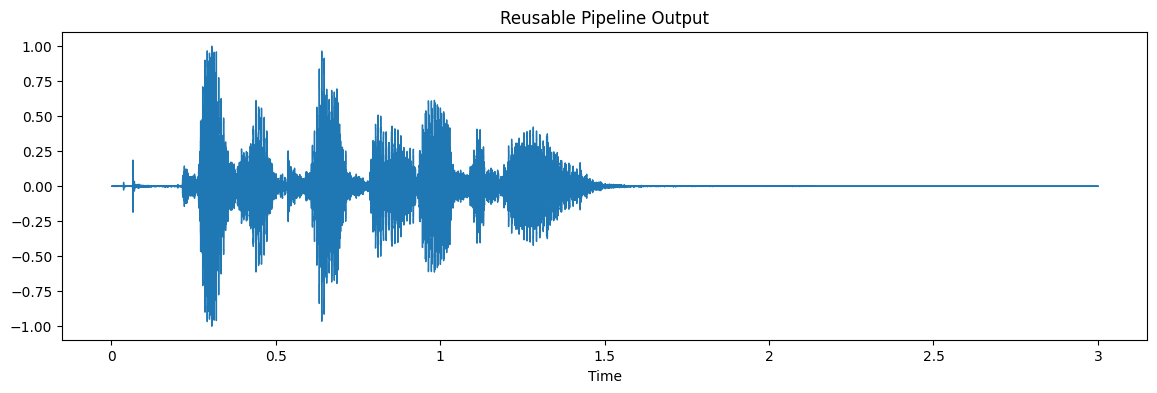

In [297]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(processed_audio, sr=sr)

plt.title("Reusable Pipeline Output")

plt.show()

In [298]:
emotion_files = [
    "dataset/Actor_01/03-01-03-01-01-01-01.wav",  # happy
    "dataset/Actor_01/03-01-04-01-01-01-01.wav",  # sad
    "dataset/Actor_01/03-01-05-01-01-01-01.wav"   # angry
]

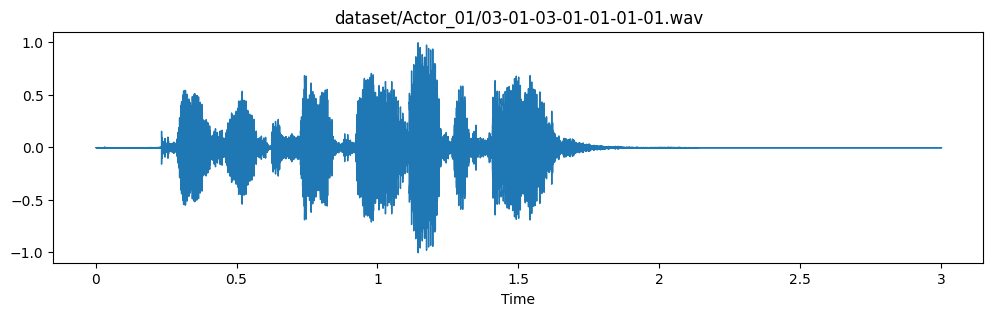

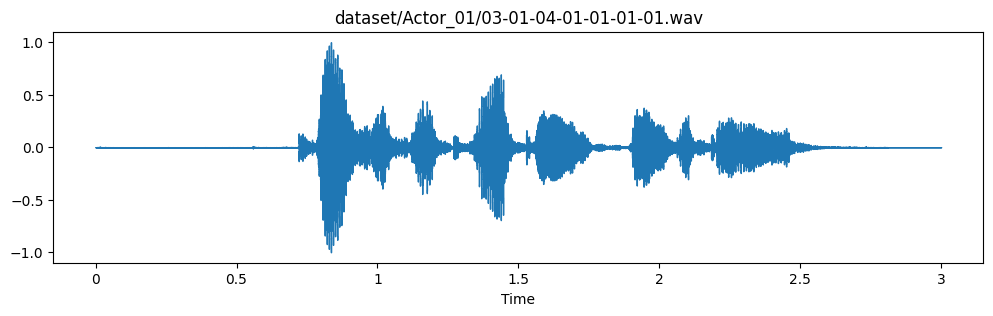

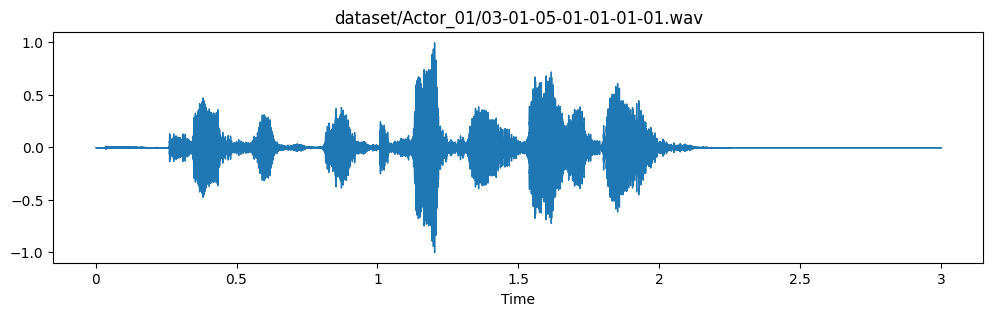

In [299]:
for file in emotion_files:

    audio, sr = preprocess_audio(file)

    plt.figure(figsize=(12,3))

    librosa.display.waveshow(audio, sr=sr)

    plt.title(file)

    plt.show()

In [300]:
import soundfile as sf

sf.write("processed_audio.wav", processed_audio, sr)

print("Processed audio saved!")

Processed audio saved!


In [301]:
dataset_path = "dataset"

all_audio = []
all_labels = []

In [302]:
emotion_map = {
    "01": "neutral",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful"
}

In [303]:
for actor_folder in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor_folder)

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.endswith(".wav"):

                emotion_code = file.split("-")[2]

                if emotion_code in emotion_map:

                    file_path = os.path.join(actor_path, file)

                    audio, sr = preprocess_audio(file_path)

                    all_audio.append(audio)

                    all_labels.append(emotion_map[emotion_code])

print("Total Processed Files:", len(all_audio))

Total Processed Files: 864


In [304]:
print("Total Labels:", len(all_labels))

print("Example Labels:")
print(all_labels[:10])

Total Labels: 864
Example Labels:
['fearful', 'angry', 'fearful', 'neutral', 'fearful', 'angry', 'sad', 'happy', 'sad', 'neutral']


#Day 4


##CREATE MFCC EXTRACTION FUNCTION

In [305]:
def extract_mfcc(audio,sr, n_mfcc = 40):
  mfcc = librosa.feature.mfcc(
      y = audio,
      sr = sr,
      n_mfcc=n_mfcc
  )

  return mfcc

##TEST MFCC EXTRACTION

In [306]:
audio_path = "dataset/Actor_01/03-01-05-01-01-01-01.wav"

audio,sr= preprocess_audio(audio_path)

mfcc_features = extract_mfcc(audio,sr)

print("MFCC Shape:", mfcc_features.shape)

MFCC Shape: (40, 130)


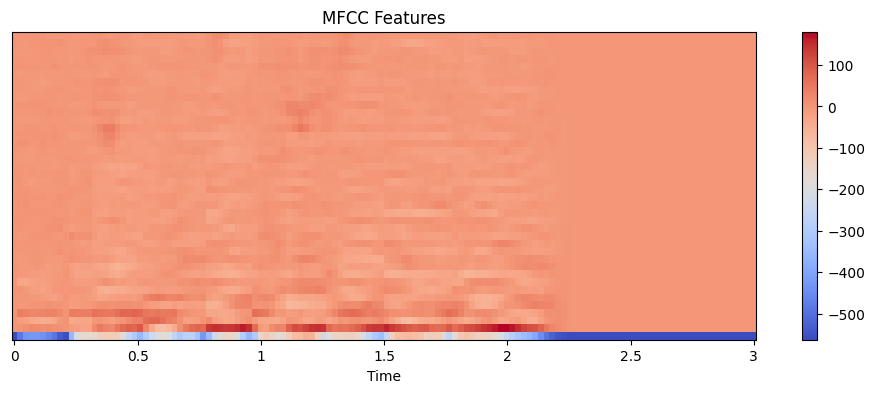

In [307]:
plt.figure(figsize=(12,4))

librosa.display.specshow(
    mfcc_features,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

##CREATING COMPLETE DATASET PIPELINE

###EMOTION MAPPINGH

In [308]:
emotion_map = {
    "01": "neutral",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful"
}

In [309]:
dataset_path = "dataset"

In [310]:
x = []
y = []

###PROCESSING ENTIRE DATASET

In [311]:
from genericpath import isdir
for actor_folder in os.listdir(dataset_path):

  actor_path = os.path.join(dataset_path,actor_folder)

  if os.path.isdir(actor_path):
    for file in os.listdir(actor_path):

      if file.endswith(".wav"):

        emotion_code = file.split("-")[2]

        if emotion_code in emotion_map:

          file_path = os.path.join(actor_path,file)

          #preprocess audio
          audio,sr = preprocess_audio(file_path)

          #Extract mfcc

          mfcc = extract_mfcc(audio,sr)

          #store features
          x.append(mfcc)

          #store label
          y.append(emotion_map[emotion_code])

print("Dataset Processing Complete!!")


Dataset Processing Complete!!


In [312]:
print("Total Samples:", len(x))
print("Total Labels:", len(y))
print("First Label:", y[0])
print("MFCC Shape:", x[0].shape)

Total Samples: 864
Total Labels: 864
First Label: fearful
MFCC Shape: (40, 130)


In [313]:
x = np.array(x)

y = np.array(y)

print("x shape:",x.shape)

print("y shape:",y.shape)


x shape: (864, 40, 130)
y shape: (864,)


###ENCODING LABELS

In [314]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(y_encoded[:10])

[1 0 1 3 1 0 4 2 4 3]


In [315]:
y_categorical = to_categorical(y_encoded)

print(y_categorical.shape)

(864, 5)


###RESHAPE FOR CNN

In [316]:
x = x[...,np.newaxis]

print("New x shape:",x.shape)

New x shape: (864, 40, 130, 1)


###TRAIN TEST SPLIT

In [317]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y_categorical,
    test_size = 0.2,
    random_state = 42
)

print("Training Samples:", x_train.shape)
print("Testing Samples:", x_test.shape)

Training Samples: (691, 40, 130, 1)
Testing Samples: (173, 40, 130, 1)


# DAY 5

In [318]:
#Importing libraries

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam


In [319]:
print("x_train Shape:", x_train.shape)
print("x_test Shape:", x_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

x_train Shape: (691, 40, 130, 1)
x_test Shape: (173, 40, 130, 1)
y_train Shape: (691, 5)
y_test Shape: (173, 5)


### Building CNN Model

In [320]:
model = Sequential()

# First Convolution Block
model.add(Input(shape=(40,130,1)))
model.add(
    Conv2D(
        filters = 32,
        kernel_size = (3,3),
        activation = 'relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Dropout(0.3))

# Second Convolution Block

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(128,activation = 'relu'))

model.add(Dropout(0.3))

model.add(
    Dense(
        y_train.shape[1],
        activation = 'softmax'
    )
)

print("CNN Model Built Successfully!")

CNN Model Built Successfully!


In [321]:
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 38, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 38, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 17, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 15872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     2,031,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,051,589 (7.83 MB)

 Trainable params: 2,051,397 (7.83 MB)

 Non-trainable params: 192 (768.00 B)

In [322]:
model.compile(

    optimizer=Adam(learning_rate=0.0005),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [323]:
sample_prediction = model.predict(x_train[:1])

print(sample_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
[[3.3213390e-04 3.6270179e-05 9.9736398e-01 2.9353944e-07 2.2673158e-03]]


In [324]:
model.save('initial_ser_model.keras')

print("Initial Model Saved!")

Initial Model Saved!


#Day 6

In [325]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

### CREATING TRAINING CALLBLOCKS

In [326]:
early_stopping = EarlyStopping(
    monitor  = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

model_checkpoint = ModelCheckpoint(
     "best_ser_model.keras",
     save_best_only = True
 )

print("Callbacks Ready!")

Callbacks Ready!


###TRAINING THE MODEL

In [327]:
history = model.fit(

    x_train,
    y_train,

    validation_data=(x_test, y_test),

    epochs=50,

    batch_size=32
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 307ms/step - accuracy: 0.2330 - loss: 2.8883 - val_accuracy: 0.2601 - val_loss: 1.5280
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3343 - loss: 1.5446 - val_accuracy: 0.2775 - val_loss: 1.4805
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3560 - loss: 1.4748 - val_accuracy: 0.2601 - val_loss: 1.6076
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3806 - loss: 1.4061 - val_accuracy: 0.2832 - val_loss: 1.5609
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4240 - loss: 1.3558 - val_accuracy: 0.3295 - val_loss: 1.3980
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4370 - loss: 1.2739 - val_accuracy: 0.3526 - val_loss: 1.4277
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4747 - loss: 1.2226 - val_accuracy: 0.3295 - val_loss: 1.4185
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5340 - loss: 1.1323 - val_accuracy: 0.4162 -

###Visualize Accuracy

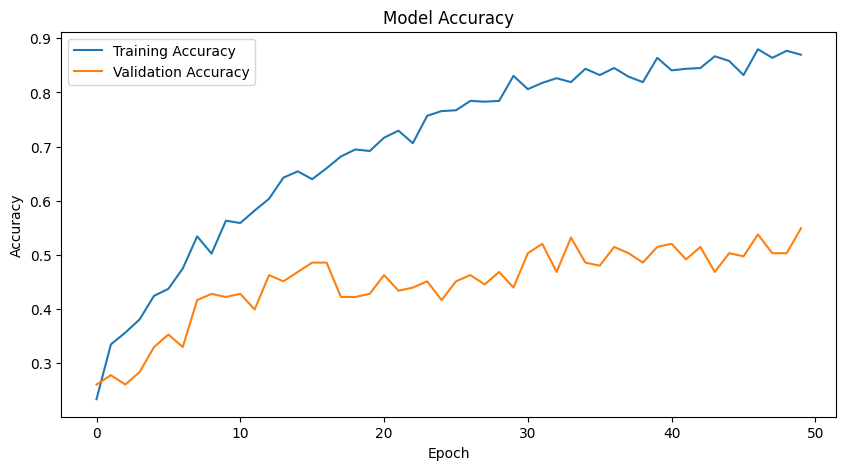

In [328]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

###Visualize Loss

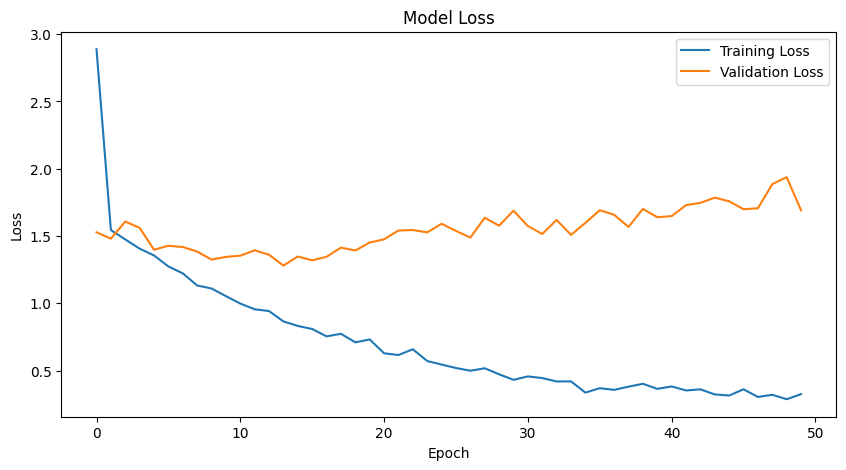

In [329]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [330]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

print("Test Loss:", test_loss)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5491 - loss: 1.6918 
Test Accuracy: 0.5491329431533813
Test Loss: 1.6917661428451538


In [331]:
prediction = model.predict(x_test[:1])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.01550848 0.57813346 0.3472281  0.04412961 0.01500041]]


In [332]:
predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)

Predicted Class: 1


In [333]:
emotion = label_encoder.inverse_transform(
    [predicted_class]
)

print("Predicted Emotion:", emotion[0])

Predicted Emotion: fearful


In [334]:
model.save("speech_emotion_model.keras")

print("Final Model Saved!")

Final Model Saved!


#Day 7

###Evaluation Libraries & prediction

In [335]:
import seaborn as sns

from sklearn.metrics import(
    confusion_matrix,
    classification_report,
    accuracy_score
)

y_pred = model.predict(x_test)

print("Predictions Generated!")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
Predictions Generated!


In [336]:
y_pred_classes = np.argmax(y_pred,axis=1)

y_true_classes = np.argmax(y_test,axis = 1)

print("Prediction Conversion Complete!!")

Prediction Conversion Complete!!


In [337]:
accuracy = accuracy_score(
    y_true_classes,
    y_pred_classes
)

print("Model Accuracy:",accuracy)

Model Accuracy: 0.5491329479768786


In [338]:
cm = confusion_matrix(
    y_true_classes,
    y_pred_classes
)

print(cm)

[[18  7  8  0  6]
 [ 0 21  8  2 10]
 [ 2  4 25  4  2]
 [ 1  1  0  7  1]
 [ 3  8  9  2 24]]


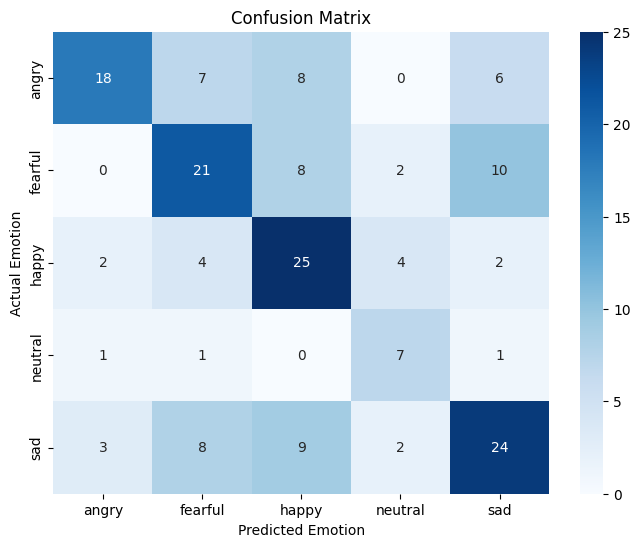

In [339]:
emotion_labels = label_encoder.classes_

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot = True,
    fmt= 'd',
    cmap = 'Blues',
    xticklabels = emotion_labels,
    yticklabels = emotion_labels
)

plt.xlabel("Predicted Emotion")

plt.ylabel("Actual Emotion")

plt.title("Confusion Matrix")

plt.show()

In [340]:
report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names = emotion_labels
)

print(report)

              precision    recall  f1-score   support

       angry       0.75      0.46      0.57        39
     fearful       0.51      0.51      0.51        41
       happy       0.50      0.68      0.57        37
     neutral       0.47      0.70      0.56        10
         sad       0.56      0.52      0.54        46

    accuracy                           0.55       173
   macro avg       0.56      0.57      0.55       173
weighted avg       0.57      0.55      0.55       173



###Creating custom audio prediction

In [341]:
def predict_emotion(audio_path):

  # Preprocess audio
  audio, sr = preprocess_audio(audio_path)

  # Extract MFCC
  mfcc = extract_mfcc(audio,sr)

  # Reshape for CNN
  mfcc = np.array(mfcc)

  mfcc = mfcc[np.newaxis,...,np.newaxis]

  #Predict

  prediction = model.predict(mfcc)

  predicted_class = np.argmax(prediction)

  predicted_emotion = label_encoder.inverse_transform(
      [predicted_class]
  )

  confidence = np.max(prediction)

  return predicted_emotion[0], confidence

In [342]:
test_audio = "dataset/Actor_01/03-01-04-01-01-02-01.wav"

emotion,confidence = predict_emotion(test_audio)

print("Predicted Emotion:",emotion)

print("Confidence:",confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Emotion: sad
Confidence: 0.99186856


In [343]:
Audio(test_audio)

###Confidence Threshold

In [344]:
def reliable_prediction(audio_path,threshold = 0.6):

  emotion,confidence = predict_emotion(audio_path)

  if confidence < threshold:

    return "Uncertain Prediction", confidence

  return emotion, confidence

In [345]:
emotion, confidence = reliable_prediction(test_audio)

print("Result:",emotion)

print("Confidence:",confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Result: sad
Confidence: 0.99186856


###Error Analysis

In [346]:
incorrect = np.where(
    y_pred_classes != y_true_classes
)[0]

print("Total Incorrect Prediction:",len(incorrect))

Total Incorrect Prediction: 78


In [347]:
for i in incorrect[:5]:

    actual = label_encoder.inverse_transform(
        [y_true_classes[i]]
    )[0]

    predicted = label_encoder.inverse_transform(
        [y_pred_classes[i]]
    )[0]

    print("Actual:", actual)

    print("Predicted:", predicted)

    print("-------------------")

Actual: sad
Predicted: fearful
-------------------
Actual: fearful
Predicted: sad
-------------------
Actual: angry
Predicted: happy
-------------------
Actual: angry
Predicted: happy
-------------------
Actual: sad
Predicted: fearful
-------------------


In [348]:
with open("classification_report.txt", "w") as file:

    file.write(report)

print("Classification Report Saved!")

Classification Report Saved!


In [349]:
model.save("industry_ready_ser_model.keras")

print("Industry-Level Model Saved!")

Industry-Level Model Saved!


#Day 8

In [350]:
#Import Libraries

import numpy as np
import librosa
import random

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [351]:
def add_noise(audio):

    noise = np.random.randn(len(audio))

    augmented_audio = audio + 0.005 * noise

    return augmented_audio

In [352]:
def pitch_shift(audio, sr):

    return librosa.effects.pitch_shift(
        audio,
        sr=sr,
        n_steps=2
    )

In [353]:
def time_stretch(audio):

    return librosa.effects.time_stretch(
        audio,
        rate=0.9
    )

In [354]:
def augment_audio(audio, sr):

    choice = random.choice([
        "noise",
        "pitch",
        "stretch"
    ])

    if choice == "noise":
        return add_noise(audio)

    elif choice == "pitch":
        return pitch_shift(audio, sr)

    elif choice == "stretch":
        return time_stretch(audio)

    return audio

In [355]:
def extract_advanced_mfcc(audio, sr):

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    mfcc = np.mean(mfcc.T, axis=0)

    return mfcc

In [356]:
X_augmented = []

y_augmented = []

In [357]:
for actor_folder in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor_folder)

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.endswith(".wav"):

                emotion_code = file.split("-")[2]

                if emotion_code in emotion_map:

                    file_path = os.path.join(actor_path, file)

                    # Preprocess
                    audio, sr = preprocess_audio(file_path)

                    # Original MFCC
                    mfcc = extract_advanced_mfcc(audio, sr)

                    X_augmented.append(mfcc)

                    y_augmented.append(
                        emotion_map[emotion_code]
                    )

                    # Augmented Audio
                    augmented = augment_audio(audio, sr)

                    mfcc_aug = extract_advanced_mfcc(
                        augmented,
                        sr
                    )

                    X_augmented.append(mfcc_aug)

                    y_augmented.append(
                        emotion_map[emotion_code]
                    )

print("Augmented Dataset Created!")

Augmented Dataset Created!


In [358]:
X_augmented = np.array(X_augmented)

y_augmented = np.array(y_augmented)

print(X_augmented.shape)
print(y_augmented.shape)

(1728, 40)
(1728,)


In [359]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    y_augmented
)

In [360]:
from tensorflow.keras.utils import to_categorical

y_categorical = to_categorical(y_encoded)

In [361]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_augmented,
    y_categorical,

    test_size=0.2,

    random_state=42
)

In [362]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)

(1382, 40, 1)


In [363]:
#ADVANCED 1D CNN MODEL

advanced_model = Sequential()

advanced_model.add(Input(shape=(40, 1)))

# First Conv Block


advanced_model.add(

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

advanced_model.add(BatchNormalization())

advanced_model.add(MaxPooling1D(pool_size=2))

advanced_model.add(Dropout(0.3))

# Second Conv Block

advanced_model.add(

    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

advanced_model.add(BatchNormalization())

advanced_model.add(MaxPooling1D(pool_size=2))

advanced_model.add(Dropout(0.3))

# Flatten

advanced_model.add(Flatten())

# Dense Layers

advanced_model.add(
    Dense(256, activation='relu')
)

advanced_model.add(Dropout(0.4))

# Output Layer

advanced_model.add(

    Dense(
        y_train.shape[1],
        activation='softmax'
    )
)

print("Advanced CNN Model Built!")

Advanced CNN Model Built!


In [364]:
advanced_model.compile(

    optimizer=Adam(learning_rate=0.0005),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [365]:
early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=7,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=3,

    min_lr=1e-6
)

In [366]:
history = advanced_model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=50,

    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.2750 - loss: 2.2874 - val_accuracy: 0.3324 - val_loss: 1.4621 - learning_rate: 5.0000e-04
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3357 - loss: 1.7079 - val_accuracy: 0.2832 - val_loss: 1.4962 - learning_rate: 5.0000e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3915 - loss: 1.5148 - val_accuracy: 0.4104 - val_loss: 1.4270 - learning_rate: 5.0000e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3980 - loss: 1.4410 - val_accuracy: 0.4306 - val_loss: 1.4291 - learning_rate: 5.0000e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4081 - loss: 1.3924 - val_accuracy: 0.4682 - val_loss: 1.3847 - learning_rate: 5.0000e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4211 - loss: 1.3594 - val_accuracy: 0.4653 - val_loss: 1.3200 - learning_rate: 5.0000e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4421 - los

In [367]:
loss, accuracy = advanced_model.evaluate(
    X_test,
    y_test
)

print("Advanced Model Accuracy:", accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8092 - loss: 0.5283 
Advanced Model Accuracy: 0.8092485666275024


In [368]:
advanced_model.save(
    "final_industry_ser_model.keras"
)

print("Final Industry Model Saved!")

Final Industry Model Saved!


In [369]:
# FINAL PREDICTION SYSTEM

def final_predict(audio_path):

    audio, sr = preprocess_audio(audio_path)

    mfcc = extract_advanced_mfcc(audio, sr)

    mfcc = mfcc[np.newaxis, ..., np.newaxis]

    mfcc = mfcc[..., np.newaxis]

    prediction = advanced_model.predict(mfcc)

    predicted_class = np.argmax(prediction)

    emotion = label_encoder.inverse_transform(
        [predicted_class]
    )[0]

    confidence = np.max(prediction)

    return emotion, confidence

In [370]:
emotion, confidence = final_predict(
    "dataset/Actor_01/03-01-04-01-01-02-01.wav"
)

print("Predicted Emotion:", emotion)

print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
Predicted Emotion: sad
Confidence: 0.7590044


In [372]:
from google.colab import files

files.download("final_industry_ser_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>